In [400]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [401]:
df = pd.read_csv('warehouse_and_retail_sales.csv')

In [402]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2026,7,20705 IMPORTS,180363,CAN' LEANDRO LES FINQUES 750ML,WINE,0.00,0.00,1.00
1,2026,7,20705 IMPORTS,171162,PROSECCO 84 - 750ML,WINE,0.00,0.00,1.00
2,2026,7,20705 IMPORTS,246778,MOSS VALPIANA SPUMANTE EXTRA DRY - 750ML,WINE,0.00,0.00,1.00
3,2026,7,20705 IMPORTS,180362,VALLDOLINA CAVA RESERVE BRUT NATURE 750ML,WINE,0.00,0.00,1.00
4,2026,7,20705 IMPORTS,180424,FENTO BICO DA RAN ALBARINO 750ML,WINE,0.00,0.00,1.00


In [403]:
df.shape

(330080, 9)

# Data Cleaning

In [404]:
df.columns = df.columns.str.lower()

In [405]:
col = ['retail sales','retail transfers','warehouse sales']
for i in col:
    df[i] = df[i].str.replace(',','',regex = False).str.replace('(','-',regex = False).str.replace(')','',regex = False).astype(float)

In [406]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330080 entries, 0 to 330079
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              330080 non-null  int64  
 1   month             330080 non-null  int64  
 2   supplier          329887 non-null  object 
 3   item code         330080 non-null  object 
 4   item description  330080 non-null  object 
 5   item type         330079 non-null  object 
 6   retail sales      330075 non-null  float64
 7   retail transfers  330080 non-null  float64
 8   warehouse sales   330080 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 22.7+ MB


In [407]:
df.describe()

,year,month,retail sales,retail transfers,warehouse sales
count,330080.000000,330080.000000,330075.000000,330080.000000,330080.000000
mean,2018.952466,6.428536,6.984240,6.930010,25.565971
std,2.171479,3.344680,31.488784,30.173479,250.547334
min,2017.000000,1.000000,-6.490000,-38.490000,-7800.000000
25%,2017.000000,3.000000,0.000000,0.000000,0.000000
50%,2019.000000,7.000000,0.290000,0.000000,1.000000
75%,2019.000000,9.000000,3.270000,3.000000,5.000000
max,2026.000000,12.000000,2923.000000,1990.830000,18317.000000


In [408]:
df.isnull().sum()

year                  0
month                 0
supplier            193
item code             0
item description      0
item type             1
retail sales          5
retail transfers      0
warehouse sales       0
dtype: int64

In [410]:
df['supplier'] = df['supplier'].fillna('Unknown')

In [411]:
df[df['item type'].isna()]

,year,month,supplier,item code,item description,item type,retail sales,retail transfers,warehouse sales
273607,2017,10,REPUBLIC NATIONAL DISTRIBUTING CO,347939,FONTANAFREDDA BAROLO SILVER LABEL 750 ML,NaN,0.0,0.0,1.0


- so according to description we can fill the item type which is NaN with the WINE type

In [412]:
df['item type'] = df['item type'].fillna('WINE')

In [413]:
df.isnull().sum()

year                0
month               0
supplier            0
item code           0
item description    0
item type           0
retail sales        5
retail transfers    0
warehouse sales     0
dtype: int64

# Co-relations

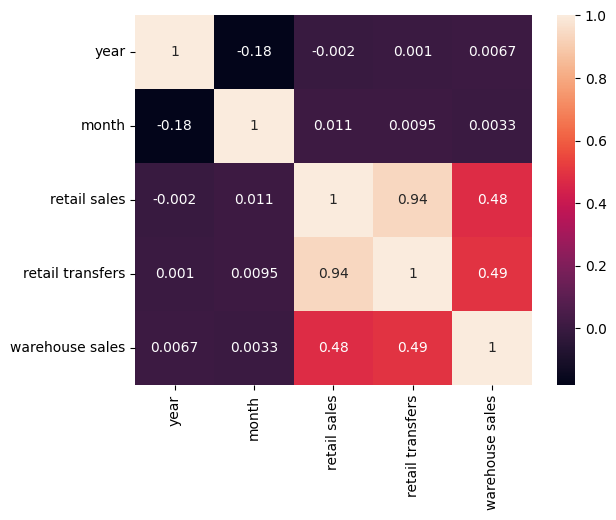

In [414]:
numerical_cols = df.select_dtypes(include = np.number).columns
correlation = df[numerical_cols].corr()
sns.heatmap(data = correlation, annot = True)
plt.show()

- Retail sales and retail transfer is having strong positive relation in which if the retail sales is more then retail transfer is also more
- This could suggest that more sale inventory transfer is happening which leads to the more/high demand of the sales

# Negative Sales

In [415]:
df[df['retail sales'] == 0][['retail sales','retail transfers','warehouse sales']].describe()

,retail sales,retail transfers,warehouse sales
count,132247.0,132247.000000,132247.000000
mean,0.0,0.106797,15.370614
std,0.0,2.609718,138.199620
min,0.0,-27.660000,-7800.000000
25%,0.0,0.000000,1.000000
50%,0.0,0.000000,2.000000
75%,0.0,0.000000,5.000000
max,0.0,256.000000,5997.060000


In [416]:
neg_retail = (df['retail transfers'] < 0).sum()
percentage_neg_retail = (df['retail transfers'] < 0).mean() * 100
print("Count of Negative Retail:",neg_retail)
print("Percentage of negative retail:",percentage_neg_retail)

Count of Negative Retail: 1032
Percentage of negative retail: 0.3126514784294716


- Negative retail transfers occur in only 0.31% of records, indicating that they are relatively rare.
- These records should be investigated as potential outbound transfers, returns, reversals, or inventory adjustments

In [417]:
neg_warehouse = (df['warehouse sales'] < 0).sum()
percentage_neg_warehouse = (df['warehouse sales'] < 0).mean() * 100
print("Count of Negative Retail:",neg_warehouse)
print("Percentage of negative retail:",percentage_neg_warehouse)

Count of Negative Retail: 740
Percentage of negative retail: 0.224188075618032


# Zero Activity

In [418]:
zero_retail_sales = (df['retail sales'] == 0).sum()

percentage = round(zero_sales / len(df) * 100,2)

print(zero_sales)
print('Percentage of Zero retail sales:',percentage,'%')

103432
Percentage of Zero retail sales: 31.34 %


In [419]:
zero_sales_transfer = (df['retail transfers'] == 0).sum()

percentage = round(zero_sales_transfer / len(df) * 100,2)

print(zero_sales_transfer)
print('Percentage of Zero retail transfers:',percentage,'%')

202749
Percentage of Zero retail transfers: 61.42 %


In [420]:
zero_warehouse_sales = (df['warehouse sales'] == 0).sum()

percentage = round(zero_warehouse_sales / len(df) * 100,2)

print(zero_warehouse_sales)
print('Percentage of Zero warehouse sales:',percentage,'%')

103432
Percentage of Zero warehouse sales: 31.34 %


# Different Types of Activities

In [421]:
conditions = [
    (df['retail sales'] == 0) &
    (df['retail transfers'] == 0) &
    (df['warehouse sales'] == 0),

    (df['retail sales'] > 0) &
    (df['retail transfers'] == 0) &
    (df['warehouse sales'] == 0),

    (df['retail sales'] == 0) &
    (df['retail transfers'] > 0) &
    (df['warehouse sales'] == 0),

    (df['retail sales'] == 0) &
    (df['retail transfers'] == 0) &
    (df['warehouse sales'] > 0)
]

choices = [
    'No Activity',
    'Retail Sales Only',
    'Retail Transfer Only',
    'Warehouse Sales Only'
]

df['activity_type'] = np.select(
    conditions,
    choices,
    default='Multiple Activities'
)

In [422]:
activityType = df['activity_type'].value_counts().reset_index(name = 'count')
activityType

,activity_type,count
0,Multiple Activities,143548
1,Warehouse Sales Only,127182
2,Retail Sales Only,56281
3,Retail Transfer Only,1921
4,No Activity,1148


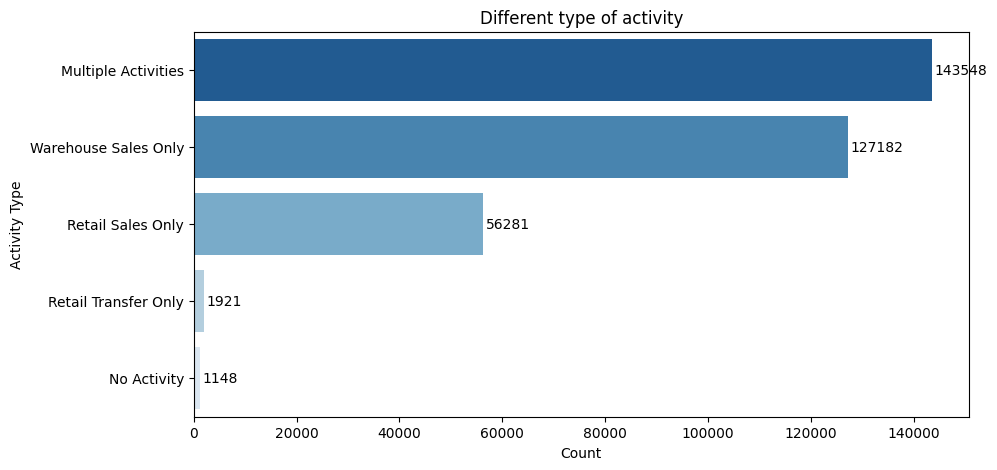

In [423]:
plt.figure(figsize = (10,5))
ax = sns.barplot(data = activityType, y = activityType['activity_type'], x = activityType['count'], palette = 'Blues_r')

for i in range(len(activityType)):
    x = activityType['count'].iloc[i]
    y = i
    plt.text(
        x + 500,
        y,
        str(activityType['count'].iloc[i]),
        ha='left',
        va='center',
        fontsize=10
    )

plt.ylabel('Activity Type')
plt.xlabel('Count')
plt.title('Different type of activity')
plt.show()

In [424]:
activity_counts = df['activity_type'].value_counts()
activity_percentage = round(activity_counts / len(df) * 100,3)

print(activity_percentage)

activity_type
Multiple Activities     43.489
Warehouse Sales Only    38.531
Retail Sales Only       17.051
Retail Transfer Only     0.582
No Activity              0.348
Name: count, dtype: float64


- A large proportion of records involve multiple types of inventory/sales activity, indicating that products frequently move through more than one channel
- Products are being sold through the warehouse channel more when compared to the retail sales or retail transfer

# Top Suppliers

In [425]:
df['supplier'].nunique()

540

In [426]:
supplier_sales = df.groupby('supplier').agg({
    'retail sales': 'sum',
    'warehouse sales': 'sum'
})

supplier_sales.head(10).reset_index()

,supplier,retail sales,warehouse sales
0,20705 IMPORTS,0.00,40.00
1,8 VINI INC,2.53,1.00
2,A HARDY USA LTD,0.56,0.00
3,A I G WINE & SPIRITS,13.24,197.00
4,A TO Z WINEWORKS LLC,59.38,54.00
5,A VINTNERS SELECTIONS,9482.87,35241.97
6,A&E INC,11.49,0.00
7,A&W BORDERS LLC,1.30,0.00
8,ADAMBA IMPORTS INTL,78.86,2.00
9,AFARO LLC,94.54,107.00


In [427]:
top_retail = supplier_sales.sort_values(
    'retail sales', ascending = False
).reset_index()

top_warehouse = supplier_sales.sort_values(
    'warehouse sales', ascending = False
).reset_index()


In [428]:
print("Top retail sales supplier is ",top_retail['supplier'][0])

Top retail sales supplier is  E & J GALLO WINERY


In [503]:
print("Top warehouse sales supplier is ",top_warehouse['supplier'][0])

Top warehouse sales supplier is  CROWN IMPORTS


# Most Inventory Movement by Item type

In [430]:
multipleActivity = df[df['activity_type'] == 'Multiple Activities']
multipleActivity.groupby('item type').agg({
    'retail sales': 'sum',
    'retail transfers': 'sum',
    'warehouse sales': 'sum'
}).reset_index()

,item type,retail sales,retail transfers,warehouse sales
0,BEER,602406.79,602567.79,5344414.64
1,DUNNAGE,0.00,0.00,-129361.00
2,KEGS,0.00,-1.00,-194.00
3,LIQUOR,839821.26,867643.78,126031.01
4,NON-ALCOHOL,30696.24,30936.87,30040.84
5,REF,418.67,388.92,-20844.00
6,STR_SUPPLIES,2749.51,2861.58,0.00
7,WINE,759968.42,770972.00,941241.12


In [431]:
multiple_activity = df[
    df['activity_type'] == 'Multiple Activities'
].copy()

multiple_activity['total_movement'] = (
    multiple_activity['retail sales'].abs() +
    multiple_activity['retail transfers'].abs() +
    multiple_activity['warehouse sales'].abs()
)

item_movement = (
    multiple_activity
    .groupby('item type')['total_movement']
    .sum()
    .sort_values(ascending=False)
)

item_movement

item type
BEER            6551141.88
WINE            2473875.26
LIQUOR          1834433.65
DUNNAGE          129361.00
NON-ALCOHOL       91743.55
REF               21651.91
STR_SUPPLIES       5611.09
KEGS                199.00
Name: total_movement, dtype: float64

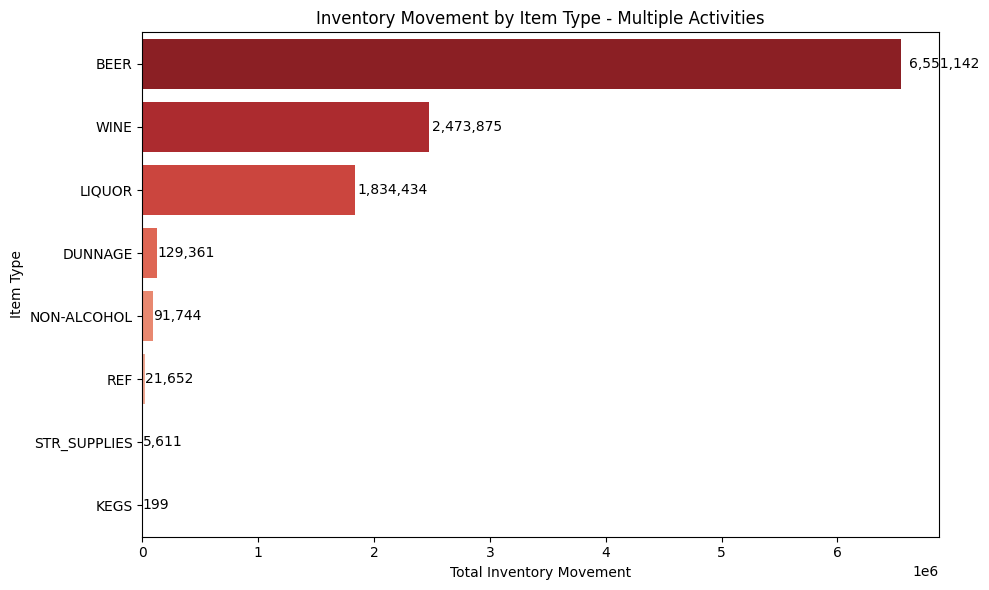

In [432]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x = item_movement.values,
    y = item_movement.index,
    palette = 'Reds_r'
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():,.0f}',
        va = 'center',
        ha = 'left'
    )
plt.xlabel('Total Inventory Movement')
plt.ylabel('Item Type')
plt.title('Inventory Movement by Item Type - Multiple Activities')
plt.tight_layout()
plt.show()

- BEER has the highest inventory movement within multiple-activity records, at approximately 6.55 million units, substantially higher than WINE (2.47 million) and LIQUOR (1.83 million).

In [433]:
beer_share = (item_movement['BEER'] / item_movement.sum() * 100)
print(f"Beer movement share: {beer_share:.2f}%")

Beer movement share: 58.98%


# Dead Stock / Inactive products

In [436]:
zero_movement = df[
    (df['retail sales'] == 0) &
    (df['retail transfers'] == 0) &
    (df['warehouse sales'] == 0)
]
item_type_zero_move = zero_movement.groupby('item type').size().sort_values(ascending = False)
supplier_zero_move = zero_movement.groupby('supplier').size().sort_values(ascending = False)
print("The Zero movement of invenotry in supplier:")
print(supplier_zero_move)
print("-----------------------------------------------")
print("The Zero movement of invenotry in item type:")
print(item_type_zero_move)

The Zero movement of invenotry in supplier:
supplier
REPUBLIC NATIONAL DISTRIBUTING CO    110
LEGENDS LTD                           80
A VINTNERS SELECTIONS                 65
MONSIEUR TOUTON SELECTION             46
OPICI FAMILY DISTRIBUTING OF MD       43
                                    ... 
WARSTEINER IMPORTERS                   1
WILLIAM GRANT AND SONS INC             1
WI INC                                 1
WILLIAM HARRISON IMPORTS               1
YUENGLING BREWERY                      1
Length: 162, dtype: int64
-----------------------------------------------
The Zero movement of invenotry in item type:
item type
WINE            767
BEER            164
LIQUOR          106
KEGS            102
NON-ALCOHOL       7
REF               1
STR_SUPPLIES      1
dtype: int64


# Trends

In [437]:
df['year'].unique()

array([2026, 2020, 2019, 2018, 2017])

In [438]:
each_year_trend = df.groupby(['year'])[['retail sales','warehouse sales','retail transfers']].sum().reset_index()

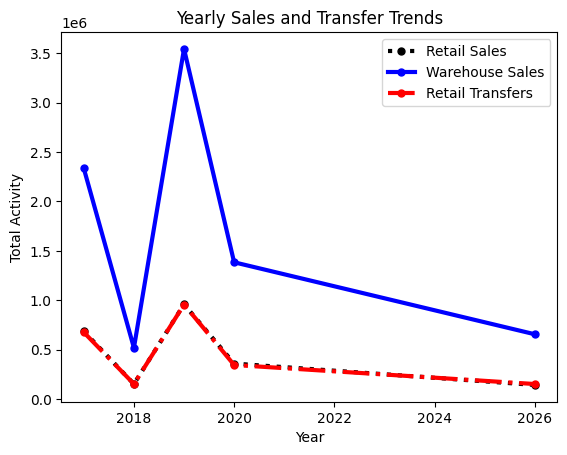

In [439]:
x = each_year_trend['year']
y1 = each_year_trend['retail sales']
y2 = each_year_trend['warehouse sales']
y3 = each_year_trend['retail transfers']
plt.plot(x,y1,marker=".",
             markersize=10,
             linestyle="dotted",   
             linewidth=3,
             color="black",
             label = 'Retail Sales'
        )

plt.plot(x,y2,marker=".",
             markersize=10,
             linestyle="solid",  
             linewidth=3,
             color="blue",
             label = 'Warehouse Sales'
        )

plt.plot(x,y3,marker=".",
             markersize=10,
             linestyle="dashdot",   
             linewidth=3,
             color="red",
             label = 'Retail Transfers'
        )
plt.legend()
plt.xlabel('Year')
plt.ylabel('Total Activity')
plt.title('Yearly Sales and Transfer Trends')
plt.legend()
plt.show()

- warehouse sales completely dominates the graph and while retail sales and transfers are much smaller
- Between the available years, warehouse sales show substantial fluctuations, peaking in 2019 and declining by 2026.
- Warehouse sales did not continuously declined from 2020 to 2026 but due to insufficient data from 2021 to 2025 

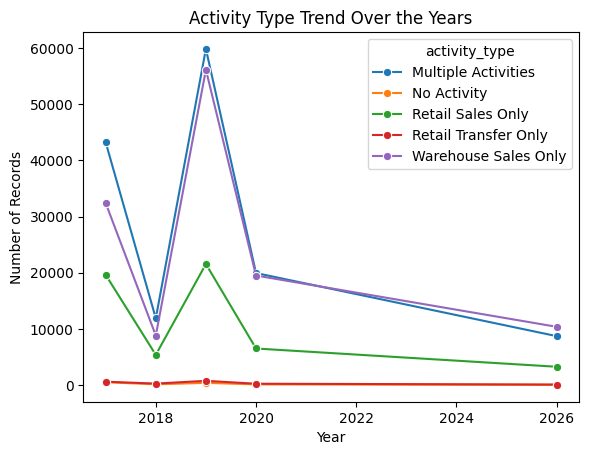

In [440]:
year_activity = (
    df.groupby(['year','activity_type']).size().reset_index(name = 'count')
)
sns.lineplot(
    data = year_activity,
    x = 'year',
    y = 'count',
    hue = 'activity_type',
    marker = 'o'
)
plt.title('Activity Type Trend Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.show()

- Multiple-activity records represent a major portion of inventory activity, indicating that products frequently experience more than one type of movement within a record.
- That suggests warehouse-related activity is a major component of the overall inventory movement.
- The number of recorded activities peaks in 2019 and is substantially lower in the later available years

# Suppliers Concentration

In [442]:
top10_suppliers = df.groupby(['supplier']).size().reset_index(name = 'count').sort_values('count', ascending = False)
top10_suppliers = top10_suppliers.head(10)
top10_suppliers

,supplier,count
382,REPUBLIC NATIONAL DISTRIBUTING CO,21006
262,LEGENDS LTD,13635
433,SOUTHERN GLAZERS WINE AND SPIRITS,13053
145,E & J GALLO WINERY,11944
467,"THE COUNTRY VINTNER, LLC DBA WINEBOW",11756
305,MONSIEUR TOUTON SELECTION,10864
5,A VINTNERS SELECTIONS,9994
39,BACCHUS IMPORTERS LTD,9150
123,DIAGEO NORTH AMERICA INC,8101
380,RELIABLE CHURCHILL LLLP,7441


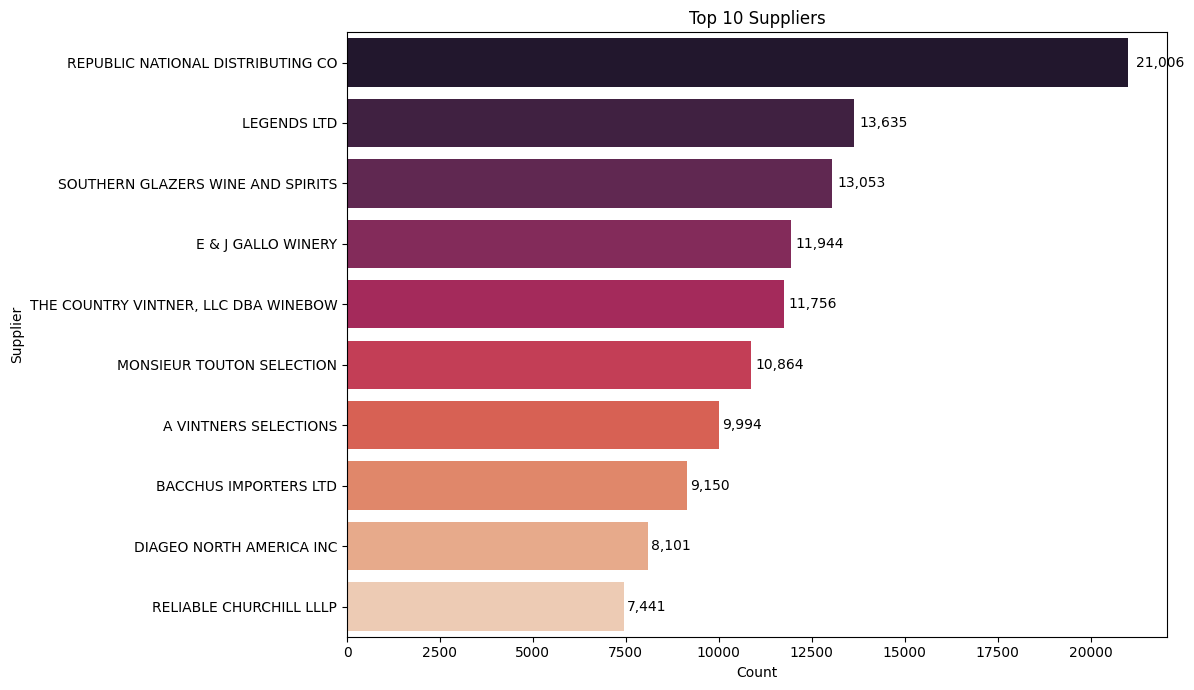

In [443]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top10_suppliers,
    x= top10_suppliers['count'],
    y= top10_suppliers['supplier'],
    palette = 'rocket'
)

for bar in ax.patches:
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():,.0f}',
        va = 'center',
        ha = 'left'
    )

plt.xlabel('Count')
plt.ylabel('Supplier')
plt.title('Top 10 Suppliers')
plt.tight_layout()
plt.show()

In [444]:
supplier_sales = (
    df.groupby('supplier')['retail sales'].sum().sort_values(ascending = False)
)
supplier_sales.head(10)
supplier_contribution = supplier_sales.reset_index()
supplier_contribution['percentage'] = (
    round(supplier_contribution['retail sales'] / supplier_contribution['retail sales'].sum() * 100,2)
)
supplier_contribution['cumulative_percentage'] = (
    supplier_contribution['percentage'].cumsum()
)
supplier_contribution = supplier_contribution.head(20)

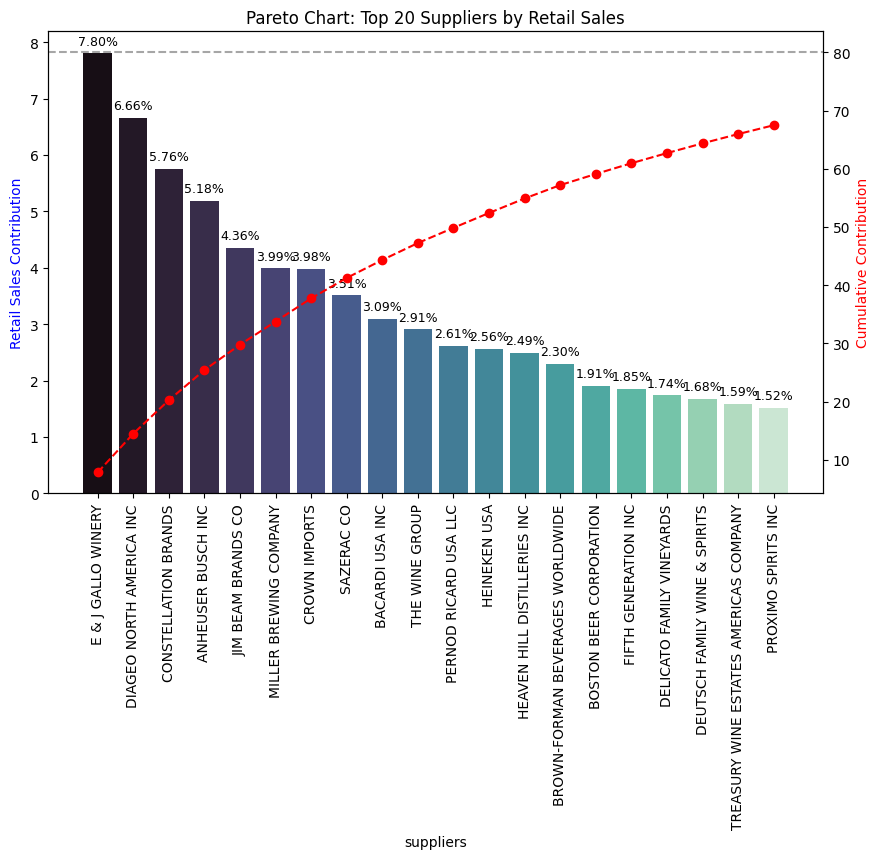

In [445]:
fig, ax1 = plt.subplots(figsize = (10,6))
sns.barplot(
    x = supplier_contribution['supplier'], 
    y = supplier_contribution['percentage'], 
    palette = 'mako', 
    ax = ax1
)
for bar in ax1.patches:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{bar.get_height():.2f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )
ax2 = ax1.twinx()
ax2.plot(
    supplier_contribution['supplier'], 
    supplier_contribution['cumulative_percentage'], 
    color = 'red', 
    marker = 'o', 
    linestyle = 'dashed'
)
ax1.set_xticklabels(supplier_contribution['supplier'],rotation = 90)
ax1.set_ylabel('Retail Sales Contribution', color='blue')
ax2.set_ylabel('Cumulative Contribution', color='red')
ax1.set_xlabel('suppliers')
ax1.set_title('Pareto Chart: Top 20 Suppliers by Retail Sales')
ax2.axhline(y=80, color="gray", linestyle='dashed', alpha=0.7)
plt.show()

- The top 20 suppliers account for approximately 70% of total retail sales, while the remaining suppliers contribute only about 30%.
- Not highly dependent on one supplier, but significantly dependent on a group of major suppliers. So supplier management should focus particularly on those top suppliers
- These top 20 suppliers are responsible for the large portion of sales so can do the supplier negotiation like lower freight cost, purchase price, discounts etc, could have a significant financial impact.

In [446]:
top20_supplier = supplier_sales.head(20).index
top20 = df[df['supplier'].isin(top20_supplier)]
others = df[~df['supplier'].isin(top20_supplier)]

In [447]:
print("Top 20 retail sales:",
      top20['retail sales'].sum())

print("Other suppliers retail sales:",
      others['retail sales'].sum())

Top 20 retail sales: 1555770.53
Other suppliers retail sales: 749552.41


In [448]:
comparison = pd.DataFrame({
    'Top 20 Suppliers': [
        top20['retail sales'].sum(),
        top20['warehouse sales'].sum(),
        top20['retail transfers'].sum()
    ],
    
    'Other Suppliers': [
        others['retail sales'].sum(),
        others['warehouse sales'].sum(),
        others['retail transfers'].sum()
    ]
}, index=[
    'Retail Sales',
    'Warehouse Sales',
    'Retail Transfers'
])

comparison_percentage = (
    comparison.div(comparison.sum(axis=1), axis=0) * 100
).round(2)

comparison_plot = comparison_percentage.reset_index()
comparison_plot

,index,Top 20 Suppliers,Other Suppliers
0,Retail Sales,67.49,32.51
1,Warehouse Sales,79.16,20.84
2,Retail Transfers,67.82,32.18


In [449]:
comparison_plot = comparison_percentage.copy()

comparison_plot.index.name = 'Activity'

comparison_plot = comparison_plot.reset_index()

comparison_plot = comparison_plot.melt(
    id_vars='Activity',
    var_name='Supplier Group',
    value_name='Contribution'
)

comparison_plot

,Activity,Supplier Group,Contribution
0,Retail Sales,Top 20 Suppliers,67.49
1,Warehouse Sales,Top 20 Suppliers,79.16
2,Retail Transfers,Top 20 Suppliers,67.82
3,Retail Sales,Other Suppliers,32.51
4,Warehouse Sales,Other Suppliers,20.84
5,Retail Transfers,Other Suppliers,32.18


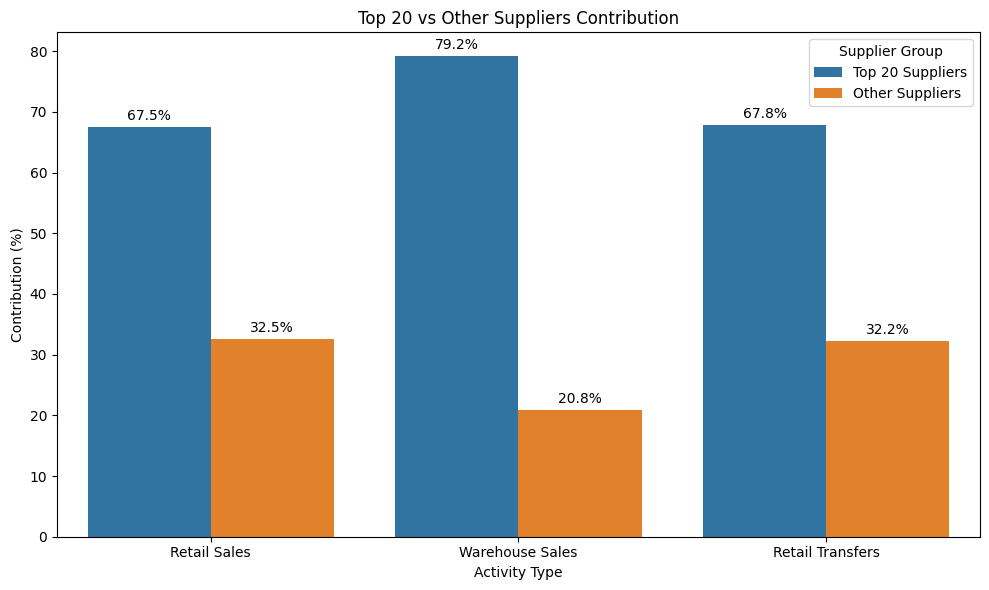

In [450]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=comparison_plot,
    x='Activity',
    y='Contribution',
    hue='Supplier Group'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        padding=3
    )

plt.xlabel('Activity Type')
plt.ylabel('Contribution (%)')
plt.title('Top 20 vs Other Suppliers Contribution')
plt.legend(title='Supplier Group')

plt.tight_layout()
plt.show()

- The business is particularly dependent on its top 20 suppliers for warehouse activity

# Suppliers Specialization

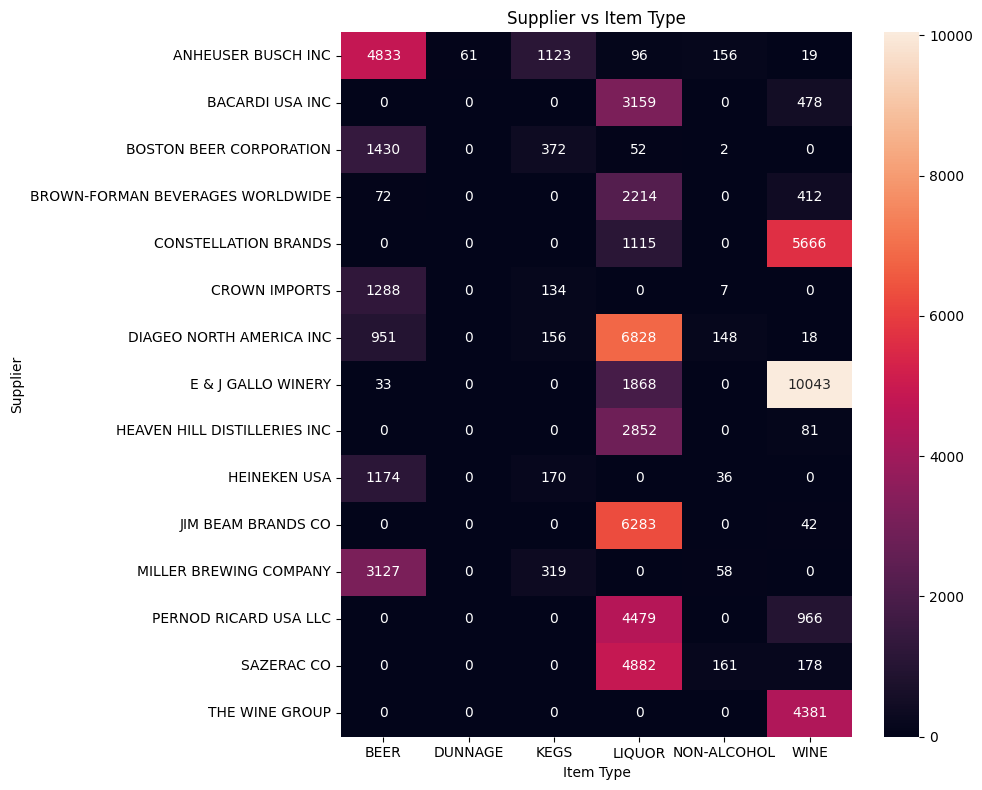

In [461]:
supplier_itemtype = pd.crosstab(
    df['supplier'],
    df['item type']
)

top_suppliers = (
    df.groupby('supplier')['retail sales'].sum().nlargest(15).index
)

heatmap_data = pd.crosstab(
    df[df['supplier'].isin(top_suppliers)]['supplier'],
    df[df['supplier'].isin(top_suppliers)]['item type'],
)

plt.figure(figsize=(10,8))
sns.heatmap(
    heatmap_data,
    annot = True,
    fmt = 'g'
)
plt.title('Supplier vs Item Type')
plt.xlabel('Item Type')
plt.ylabel('Supplier')
plt.tight_layout()
plt.show()

- Major suppliers exhibit strong category specialization, with certain suppliers predominantly serving beer, liquor, or wine. This specialization should be considered when assessing supplier dependency and identifying alternative suppliers.

# Suppliers Distribution

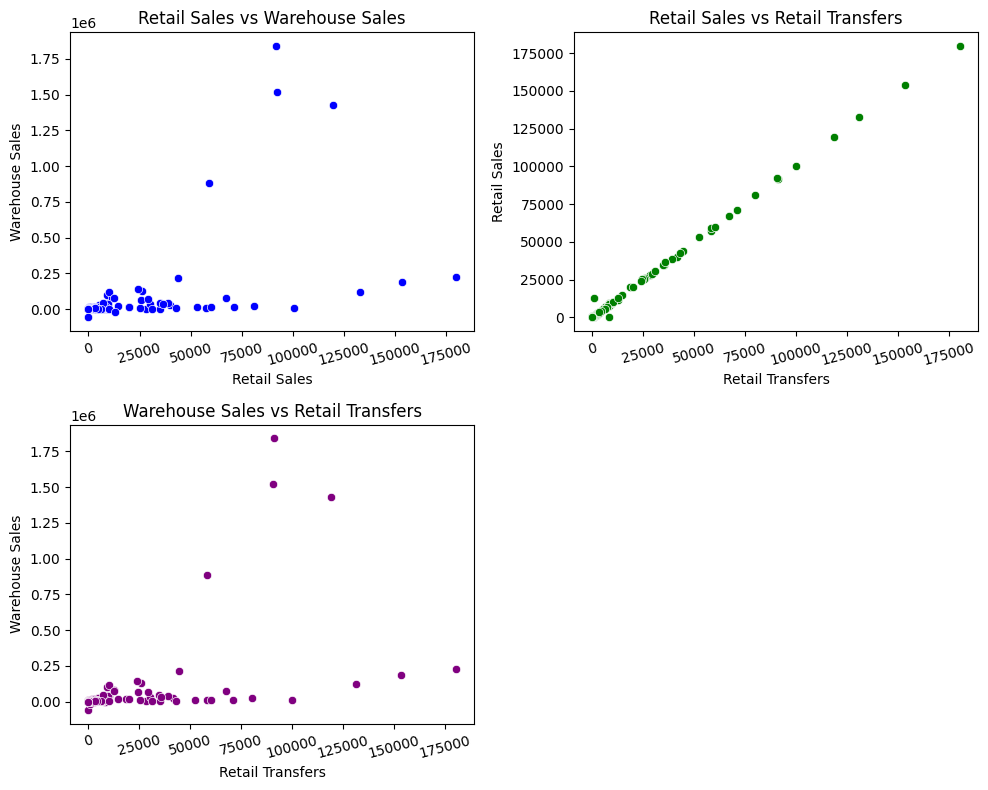

In [495]:
supplier_channel = df.groupby('supplier').agg({
    'retail sales': 'sum',
    'warehouse sales': 'sum',
    'retail transfers': 'sum'
}).reset_index()

plt.figure(figsize=(10,8))

plt.subplot(2, 2, 1)  # Grid of 1 row, 3 columns, position 1
sns.scatterplot(data=supplier_channel, x='retail sales', y='warehouse sales', color='blue')
plt.xlabel('Retail Sales')
plt.ylabel('Warehouse Sales')
plt.title('Retail Sales vs Warehouse Sales')
plt.xticks(rotation=15)

plt.subplot(2, 2, 2)  # Grid of 1 row, 3 columns, position 2
sns.scatterplot(data=supplier_channel, x='retail transfers', y='retail sales', color='green')
plt.xlabel('Retail Transfers')
plt.ylabel('Retail Sales')
plt.title('Retail Sales vs Retail Transfers')
plt.xticks(rotation=15)

plt.subplot(2, 2, 3)  # Grid of 1 row, 3 columns, position 3
sns.scatterplot(data=supplier_channel, x='retail transfers', y='warehouse sales', color='purple')
plt.xlabel('Retail Transfers')
plt.ylabel('Warehouse Sales')
plt.title('Warehouse Sales vs Retail Transfers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

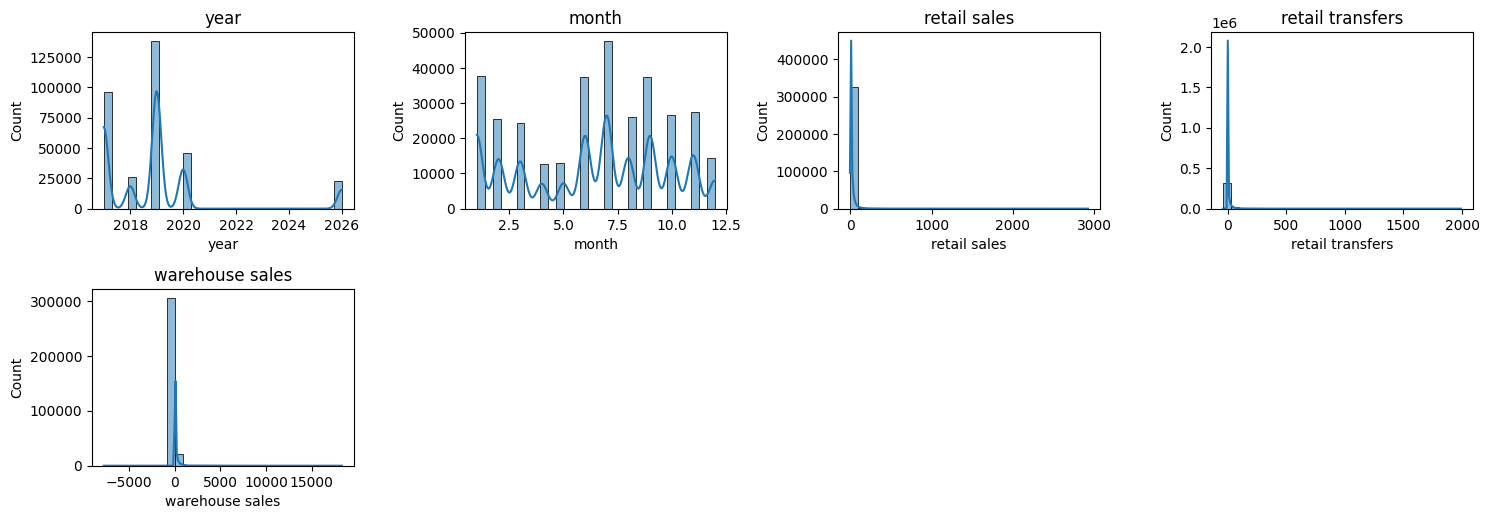

In [269]:
numerical_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)  # grid layout   # plt.subplot(rows, columns, position)
    sns.histplot(df[col], kde = True, bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()
# numerical_cols

- Retail sales are highly right-skewed across the dataset, with a large concentration of zero or low-sales records
- Most transfer values are close to zero, while a small number have much larger transfer quantities.

# Outliers

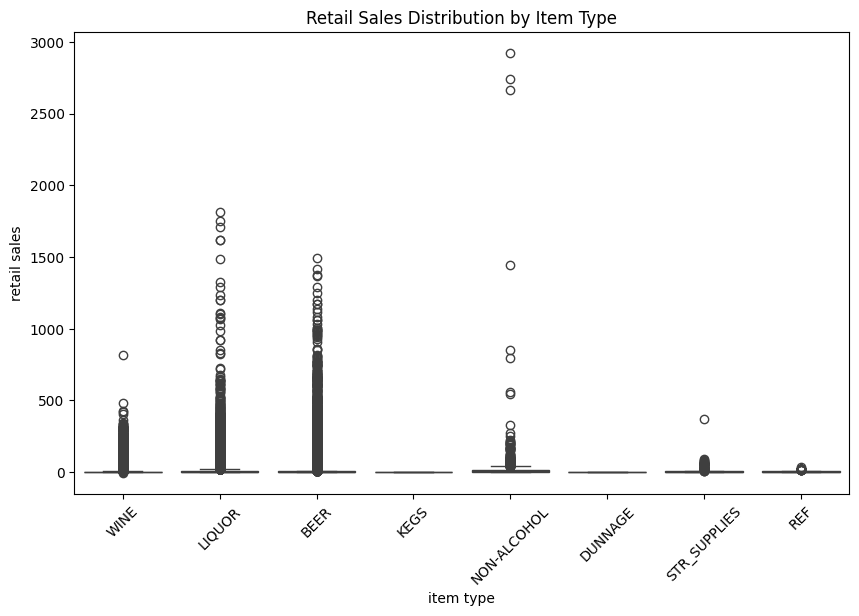

In [479]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='item type',
    y='retail sales'
)
plt.xticks(rotation=45)
plt.title('Retail Sales Distribution by Item Type')
plt.show()

- Retail sales are highly skewed, with many low/zero observations and a relatively small number of very high-sales observations.
- Beer, Liquor and Wine contain numerous high-sales observations, while Non-Alcohol shows some particularly extreme individual sales values.
- This indicates that sales are not evenly distributed across products, making outlier analysis and segmentation important for identifying high-performing products.